# EDA Notebook - Context

## Changelog vs v2

Functions:
- Standardized functions from the ds_toolkit.

EDA:
- Kept Sweetviz for log, but enchanced validating now 10 hypotheses (vs 2 of v2), evaluating now churn rates vs each variable. 
- Proposed feature engineering.

Whole code: 
- Minor fixes and general comments.

## Planning

Business problem:
- The financial institution has an estimated churn retention rate of 28%/year.
- A new retention goal was announced for next year, which is 40%. To achieve this, the customer retention team needs a churn prediction model.
- The model must be at least 55% effective in identifying true churners, while avoiding false positives.
- This way, the retention team will act using the model to reverse at least 80% of churns, which results in 44% retention, reaching the goal.

Problem type: Binary Classification
- The 'abandono_clientes.csv' dataset contains 10k rows and 13 features, which is enough to create a supervised machine learning model using a frequentist approach.
- To deal with this churn problem, some classification models with different approaches will be created, and the best one will be used.

Evaluation metric: F1 score 
- F1 score will be the metric used with cross-validation, considering:
    - The business team needs a good balance between finding actual churners (recall) and avoiding false alarms (precision). 
    - Focuses on minority class (churners) performance without being skewed by majority class dominance (imbalanced dataset: 20% churned).

Methodology: CRISP-DM
- Cross Industry Standard Process for Data Mining methodology will be used, being cyclical and flexible, in order to take advantage of best market practices.

Project deliverables:
- EDA Notebook with:
    - Statistical analysis of data.
    - Business Insights from variables.
- Modeling Notebook with: 
    - Churn prediction model with a baseline > 0.55 on test data: 55% effectiveness in identifying true churners.
    - Model Explainability.
    - Business and financial results.
- CSV file with:
    - 'abandono_result.csv' file, being the model predictions from 'abandono_teste.csv'.

# Imports

In [34]:
import pandas                    as pd
import numpy                     as np
import seaborn                   as sns
from matplotlib                  import pyplot as plt

#sklearn
from sklearn.model_selection     import train_test_split 
from sklearn.pipeline            import Pipeline
from sklearn.base                import BaseEstimator, TransformerMixin

#sv
import sweetviz as sv  #requires numpy downgrade (numpy==1.26.0)
# Mute Matplotlib's font logger on SV report generation
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

#format
pd.set_option('display.max_columns', None)


###########################################
# https://github.com/nortonvanz/ds_toolkit/
from ds_toolkit.eda import statistics, inspect_outliers, plot_target_distribution, plot_numerical_distributions, plot_categorical_distributions, plot_numerical_correlations, plot_categorical_correlations, test_statistical_significance, plot_comprehensive_target_distribution  # EDA functions
from ds_toolkit.transformers import RenameDfColumns, FilterFeatures  # Pipeline functions


## Functions

Pass (ds_toolkit)

# Load Data

## Data Dictionary

|  Column   | Meaning   |
| :-------  | :------- |
| **RowNumber** | Record number |
| **CustomerId** | Customer ID |
| **Surname** | Customer's last name |
| **CreditScore** | Customer's credit score |
| **Geography** | Customer's country of residence |
| **Gender** | Customer's gender |
| **Age** | Customer's age |
| **Tenure** | Number of years that the customer has been a client of the institution |
| **Balande** | Ammount of money the client have on it's account |
| **NumOfProducts** | Number of products that a customer has purchased through the institution |
| **HasCrCard** | Denotes whether or not a customer has a credit card with the institution. [1 - has credit card; 0 - dosen't have credit card] |
| **IsActiveMember** | Denotes whether client is active or not. [1 - active; 0 - non active ] |
| **EstimatedSalary** | Customer's estimated anual salary |
| **Exited** | Denotes whether the client has an account at the institution. [1 - Client has exited instittion; 0 - client dosen't have exited institution] |

Load Data:

In [13]:
df_raw = pd.read_csv('../data/train/abandono_clientes.csv')
df_raw.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


## Data Split

In [14]:
train, test = train_test_split( df_raw, train_size=0.80, test_size=0.20, random_state=98, stratify=df_raw.Exited, shuffle=True)
train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

print(f'Train Size: {len(train):} ({len(train)/len(df_raw):.1%})')
print(f'Test Size: {len(test):} ({len(test)/len(df_raw):.1%})')

Train Size: 8000 (80.0%)
Test Size: 2000 (20.0%)


In [15]:
# 1. Calculate churn proportions
train_churn = train['Exited'].value_counts(normalize=True).rename('Train Share')
test_churn = test['Exited'].value_counts(normalize=True).rename('Test Share')

# 2. Combine into a quick summary table
target_comparison = pd.concat([train_churn, test_churn], axis=1)
target_comparison['Difference'] = (target_comparison['Train Share'] - target_comparison['Test Share']).abs()
print("--- Target Distribution Check ---")
print(target_comparison.round(4))

--- Target Distribution Check ---
        Train Share  Test Share  Difference
Exited                                     
0            0.7962      0.7965      0.0002
1            0.2037      0.2035      0.0003


Division is ok.

# Cleaning

Note: preprocessing applied here is for EDA exploration only.
The definitive pipeline (rename, filter, feature engineering) is implemented in the modeling notebook, applied to both train and test.

## Rename Features

In [16]:
#Rename columns (snake_case) with Pipeline 
pipe_rename_features = Pipeline([
    ('rename_features', RenameDfColumns())
])

train = pipe_rename_features.fit_transform(train)
train.head(2)

,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,2603,15683521,Godfrey,594,Germany,Male,28,0,142574.71,2,1,0,129084.82,0
1,4606,15585599,Stone,530,France,Female,34,8,0.00,2,0,1,141872.52,0


## DTypes and Missings

In [17]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_number        8000 non-null   int64  
 1   customer_id       8000 non-null   int64  
 2   surname           8000 non-null   str    
 3   credit_score      8000 non-null   int64  
 4   geography         8000 non-null   str    
 5   gender            8000 non-null   str    
 6   age               8000 non-null   int64  
 7   tenure            8000 non-null   int64  
 8   balance           8000 non-null   float64
 9   num_of_products   8000 non-null   int64  
 10  has_cr_card       8000 non-null   int64  
 11  is_active_member  8000 non-null   int64  
 12  estimated_salary  8000 non-null   float64
 13  exited            8000 non-null   int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1013.6 KB


No missings, dtypes ok.

## Duplicates

In [18]:
# Check duplicated rows
train[train.duplicated()]

,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited


No duplicated rows.

# Business-Driven Feat Engineering

This project separates feature engineering into two distinct categories based on their origin and objective, mapping directly to the iterative loops of the CRISP-DM methodology.

1. Business Structural Feature Engineering (Domain-Driven)
* Objective: Derived attributes based on core business logic, intended to help both the model and the business teams better understand and segment the data.
* Placement: Executed right after the initial Data Cleaning phase, to ensure the foundational columns are clean and consistent before engineering the structural business features used in the subsequent EDA.
* Example: Knowing that the business treats individuals (PF) and corporations (PJ) completely differently, a new customer_type variable is created here so it can be utilized throughout the entire EDA.

2. Model-Assisting Feature Engineering (Data-Driven)
* Objective: Features that are discovered empirically to help the machine learning models capture complex or non-linear patterns.
* Placement: Consolidated into a structured transformation pipeline (class) immediately after Hypothesis Validation, followed by a targeted inspection of the new variables.
* Example: Discovering during bivariate analysis that risk spikes dramatically below a certain threshold on a continuous credit score variable, leading to the creation of a binary has_low_credit_score flag.

In [19]:
train[:1]

,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,2603,15683521,Godfrey,594,Germany,Male,28,0,142574.71,2,1,0,129084.82,0


No new features will be created here during this cycle.

## Feature Filtering

Remove unnecessary features:

In [20]:
# Remove features with Pipeline
pipe_filter_features = Pipeline([
    ('filter_features', FilterFeatures(columns=['row_number', 'customer_id', 'surname']))
])

# Filter columns using Pipeline
train = pipe_filter_features.fit_transform(train)  #since `FilterFeatures` just drops columns (stateless transformer), both `fit_transform` and `transform` produce the same result. but fit_transform is preferred for consistency with sklearn API.
train[:1]

,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,594,Germany,Male,28,0,142574.71,2,1,0,129084.82,0


## Outliers

Outliers will be identified using the Interquartile Range (IQR) method, which is a statistical technique commonly used for outlier detection.
- This method is based on the assumption that the data within 1.5 times the IQR above Q3 or below Q1 represents the "normal" range of values, while anything beyond these limits is considered unusual enough to be classified as an outlier.

In [21]:
# Identify numeric columns
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

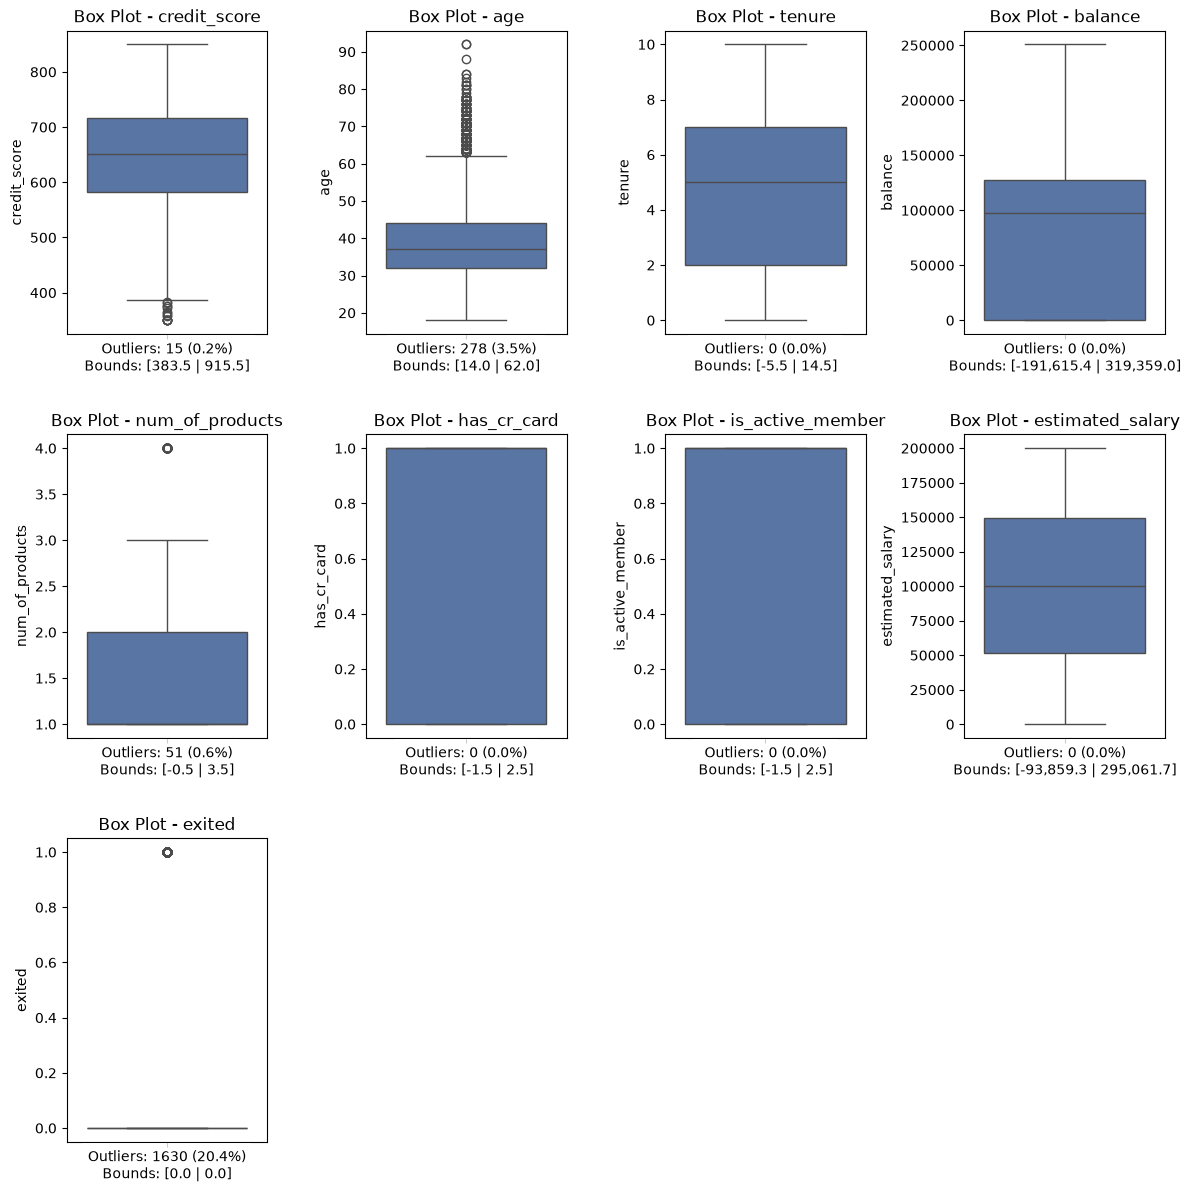

In [22]:
# Visualize and analyze outliers in numeric features using box plots and IQR method
inspect_outliers(train, numeric_cols)

Considerations:
- Outliers were identified on features: credit score, age, mum_of_products and exited.
- Examining the values considered outliers, it is visible that they are actually acceptable values for each features, like and age > 62.
- Therefore, they won't be considered outliers, and won't be removed from the dataset.

# EDA

## Univariate Analysis

### Descriptive Analysis

Composed of:
- Location Metrics (central tendency), that show where the data is centered, such as mean and median.
- Variability Metrics (dispersion), that reveal how the values are spread around that center, such as standard deviation, quantiles, skewness and kurtosis.

Below, all the numerical variables in the dataset will be analyzed.

In [23]:
statistics(train)

,non-null,range,min,quant25,median,quant75,max,mean,std,skew,kurtosis
credit_score,8000,500.0,350.0,583.0,652.0,716.0,850.0,649.9,96.7,-0.1,-0.4
age,8000,74.0,18.0,32.0,37.0,44.0,92.0,38.9,10.4,1.0,1.4
tenure,8000,10.0,0.0,2.0,5.0,7.0,10.0,5.0,2.9,0.0,-1.2
balance,8000,250898.1,0.0,0.0,97276.1,127743.6,250898.1,76673.7,62487.0,-0.1,-1.5
num_of_products,8000,3.0,1.0,1.0,1.0,2.0,4.0,1.5,0.6,0.8,0.6
has_cr_card,8000,1.0,0.0,0.0,1.0,1.0,1.0,0.7,0.5,-0.9,-1.2
is_active_member,8000,1.0,0.0,0.0,1.0,1.0,1.0,0.5,0.5,-0.1,-2.0
estimated_salary,8000,199902.4,90.1,51986.1,100487.7,149216.3,199992.5,100467.8,57274.2,-0.0,-1.2
exited,8000,1.0,0.0,0.0,0.0,0.0,1.0,0.2,0.4,1.5,0.2


Analysis:
- age: has positive kurtosis, so there is a spike arround the median.
- balance: quant25 shows 0.00, meaning at least 25% of data equals to zero. No negative values were found.
- num_of_products: max is 4, but median is 1, so at least 50% of customers have only 1 product.
- has_cr_card: negative skew shows that the concentration of values is high, so most customers have a credit card.
- estimated_salary: skew 0.00 shows that estimated salaries are not concentrated in low or high values, having an uniform distribuition.
- exited: positive skew shows that the concentration of values is low, with most values being zero, as expected for a churn problem.

### Target Analysis

Inspect the distribution of target variable with percentage labels.

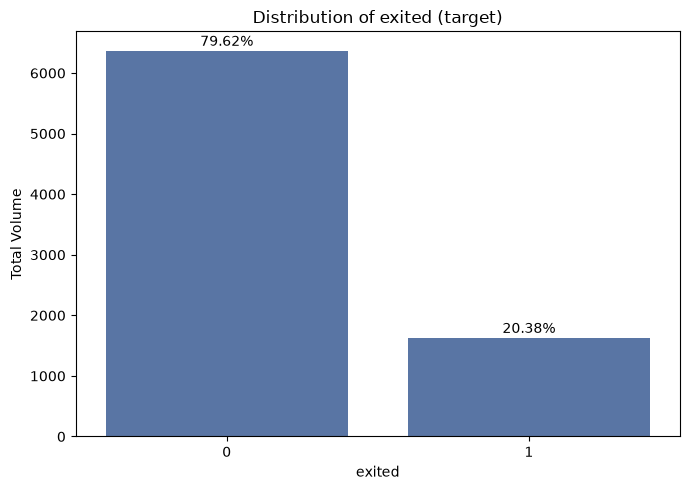

In [24]:
plot_target_distribution(train, 'exited', figsize=(7, 5))

As seen in descriptive analysis, this is an imbalanced dataset, with 20.4% of customers having churned.

### Numerical Analysis

 Inspect distributions of numerical features with histograms and KDE.

In [25]:
# Select numerical features 
train_num = train.select_dtypes(include=['int64', 'float64'])

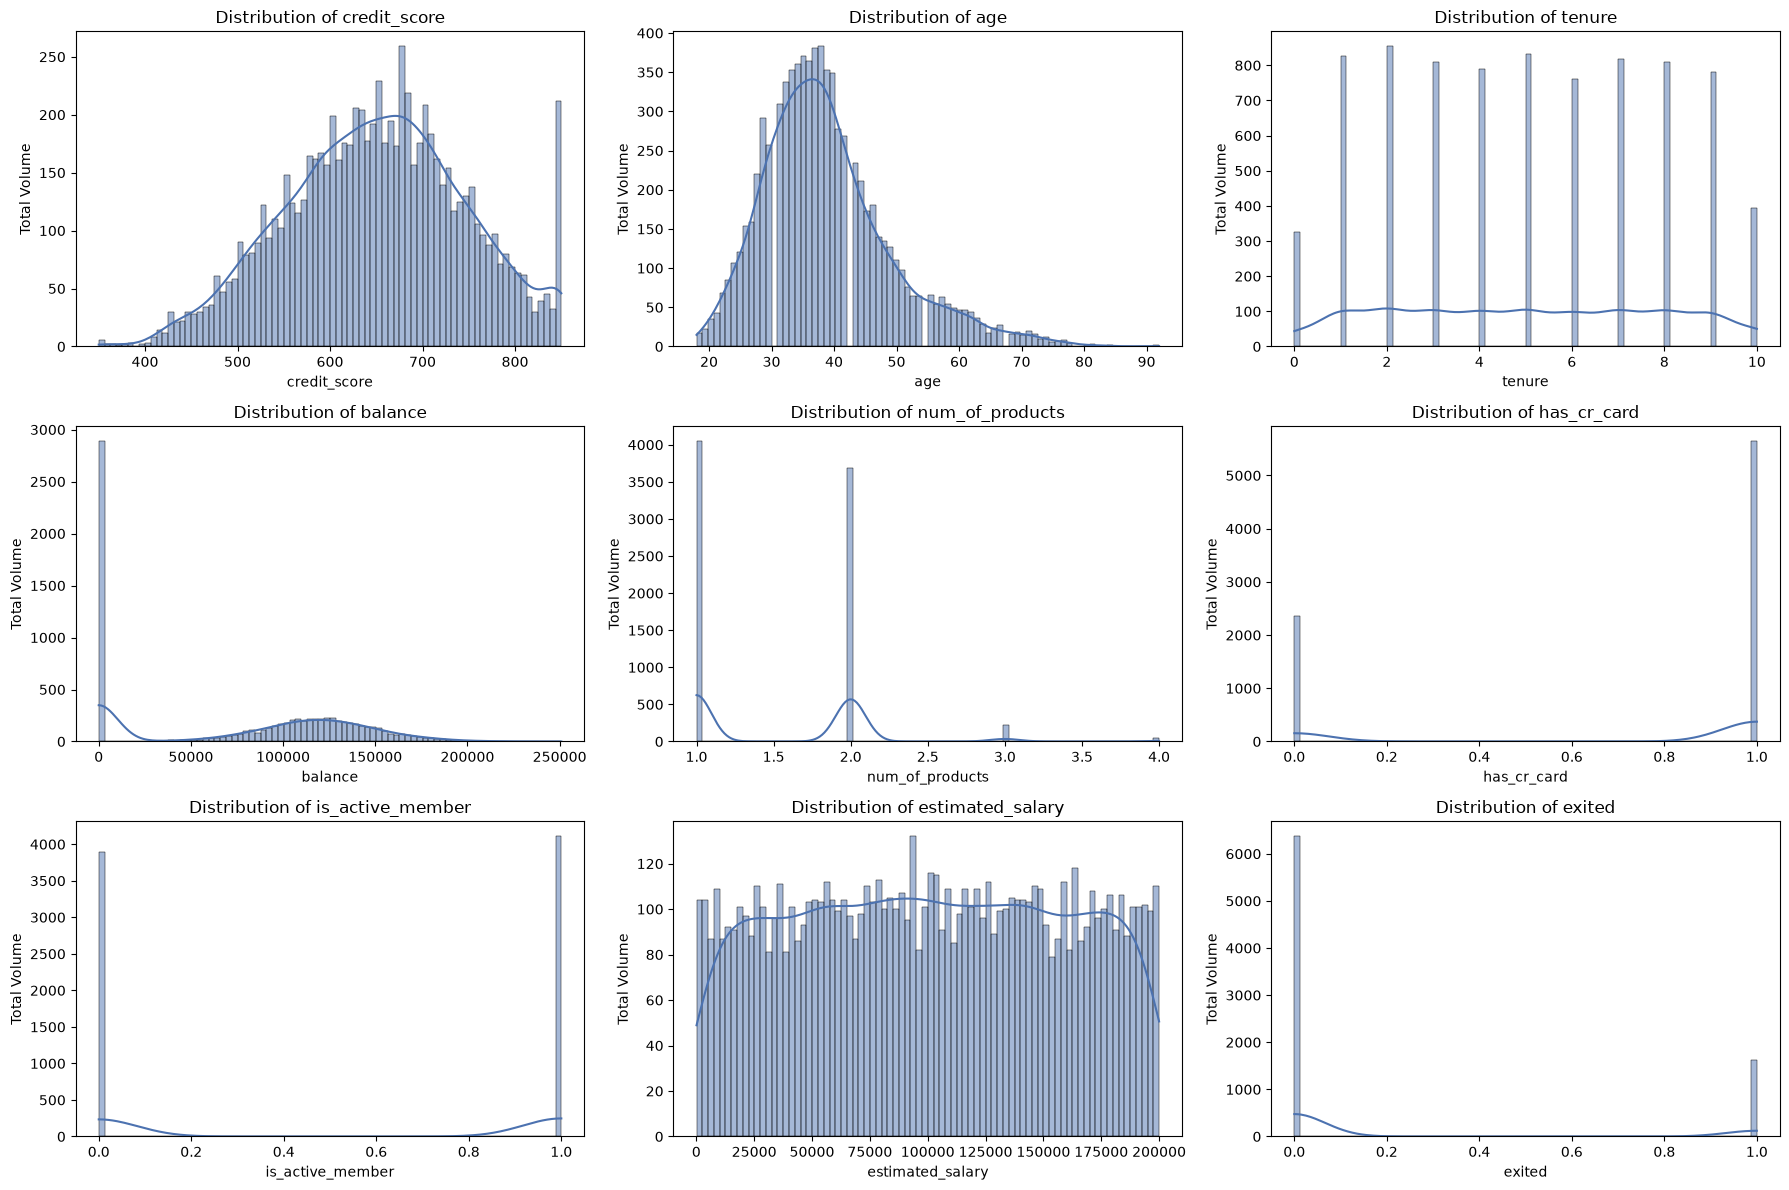

In [26]:
plot_numerical_distributions(train_num, figsize=(18, 4))

Considerations:

- Credit score: median is 652, so half of customers have score between 650 and 850. 
  - There is a spike on the right of the graph. I will inspect it:

In [27]:
# Inspect credit_score = 850
train_num.loc[train_num.credit_score == 850].credit_score.count()

184

- There are 184 customers with credit_score = 850:
  - There is really a spike on 850. Maybe it is the greatest value a customer can achieve. This may be validated with business team.
- Age: mean age is 39, and most frequent ages are betweem 30 and 40 years.
- Tenure: distribution is very homoegeneous, except for customers with 0 or 10 years.
- Balance: also has a spike on zero, but seems natural.
- Num of products: customers with more 3 or 4 products are really exceptions.
- Salary: distribuition is very uniform, except at the extremes.


### Categorical Analysis

Inspect distributions of categorical features using count plots.

In [28]:
# Select categorical features 
train_cat = train.select_dtypes(exclude=['int64', 'float64'])

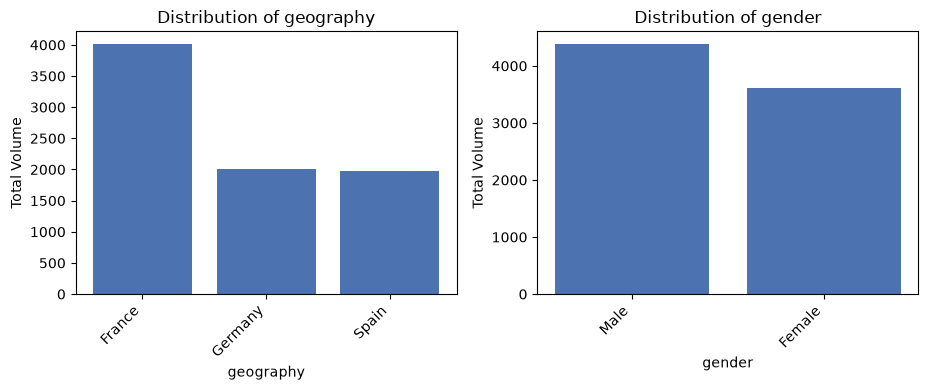

In [29]:
plot_categorical_distributions(train_cat, max_categories=12, figsize=(14, 4))

Considerations:
- Geography: Half of customers of train dataset are from france.
- Gender: Male gender has a bit more customers than Female.

## Multivariate Analysis

### Numerical Correlation 

Pearson's correlation coefficient will be used to measure the strength and direction of the linear relationship between numeric variables.
- Interpretation: Ranges from -1 to +1:
  - -1 = perfect negative correlation.
  - 0 = no correlation.
  - 1 = perfect correlation.  

- Assumptions:
    - Continuous variables, even on different scales.
    - Linearity: features must have a linear relationship.
    - Outliers: Sensitive to outliers.
    - Normality: more important for statistical significance, and less for the interpretation of the coefficient value.
    - Homoscedasticity: Variance of residuals should be constant.
    - Data independence: Observations must be independent.


Plot Pearson correlation matrix for numerical variables.

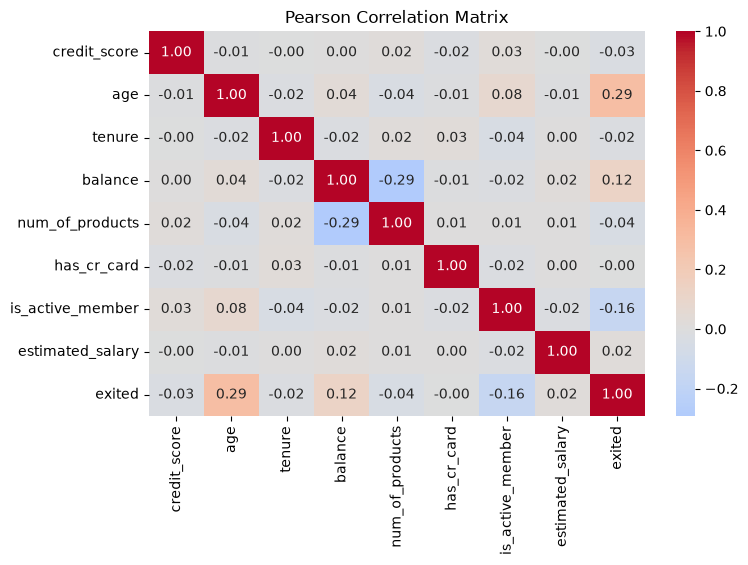

In [30]:
plot_numerical_correlations(train_num, figsize=(8, 5))

Correlation Considerations:
- age and exited: shows the strongest positive correlation (0.29). This suggests older customers are more likely to churn.
- is_active_member and exited: shows some negative correlation (-0.16). This suggests active members are less likely to churn. 
- balance and exited: shows a weak positive correlation (0.12). This suggests customers with higher balances have a slightly higher tendency to churn.

These correlations will be examined in detail during the hypotheses validation.

Feature Interactions:
- balance and num_of_products: shows the strongest negative correlation (-0.29) among features. This suggests customers with higher balances tend to have fewer products.

Possible feature engineering:
- balance_per_pruduct (balance / num_of_products). This represents the depth of the customer's financial relationship per product. If num_of_products = 0, then 0. This will make it easier for the trees to identify this feature interaction.

### Categorical Correlation

Cramér's V statistical measure, based on chi-square statistic, will be used to evaluate the strength of overall association between categorical variables.

- Interpretation: ranges from 0 (no association) to 1 (perfect association):
    - 0.0 to 0.1: Negligible association
    - 0.1 to 0.3: Weak association
    - 0.3 to 0.5: Moderate association
    - 0.5 to 0.7: Strong association
    - 0.7 to 1.0: Very strong association

Assumptions:
- Categorical variables.
- Independence between the vars.
- Sample size: more reliable results are obtained with larger sample sizes.
- Frequency distribution: Each cell in contingency table should have expected frequency ≥ 5. This ensures chi-square test validity.

In [31]:
# Combine categorical features with target
train_cat_with_tgt = pd.concat([train_cat, train_num['exited']], axis=1)

Plot Cramér's V correlations between categorical variables as a heatmap.

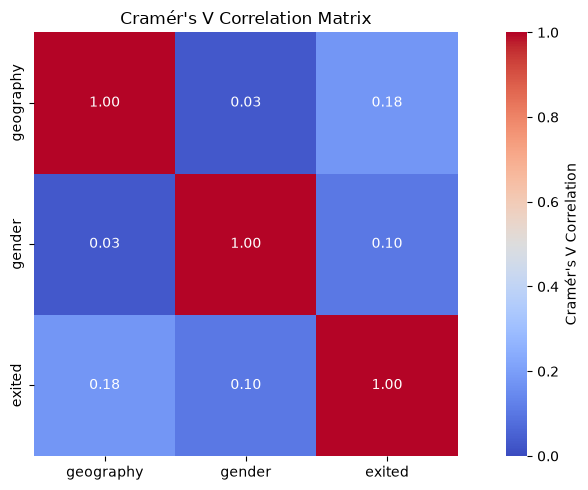

In [32]:
plot_categorical_correlations(train_cat_with_tgt, max_unique_values=50)

Correlation Considerations:
- geography and exiter: shows some positive correlation (0.18). This suggests customer location has some influence on churn behavior.
- gender and exited: shows a weak positive correlation (0.10). This suggests gender has a minor but noticeable influence on churn.

These correlations will also be examined in detail during the hypotheses validation.

## Bivariate Analysis

### Sweetviz Overview  

An overview will be performed using Sweetviz plots. 

Full report is available on reports/sv_report.html.

In [35]:
#Generate report
sv_report_df = sv.analyze(train, target_feat="exited") 
sv_report_df.show_html(filepath='../reports/sv_report.html',open_browser=False)

                                             |          | [  0%]   00:00 -> (? left)

Report ../reports/sv_report.html was generated.


The SweetViz report shows that:

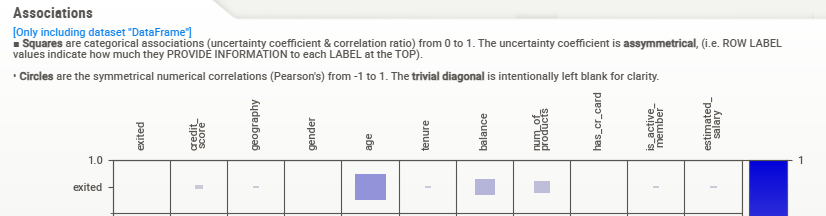
- churn (exited) -> is mostly associated categorically with: age, balance and num_of_products.
- is_active_member = 1 has low correlation with exited = 1.

### Hypotheses Validation

Sweetviz showed some interesting insights. Some hypotheses will be validated from the report.

Note: 
- With n > 1,000, statistical significance is almost guaranteed for any visible difference. 
- Given the sample size is much higher, visual differences of this magnitude are statistically significant by default. 
- Effect sizes are reported instead of p-values as they carry more business meaning.

#### H1 - The higher the credit_score, the lower the churn rate

Sweetviz overview: 
- Credit score -> as the customer's credit score increases, churn seems to drop.

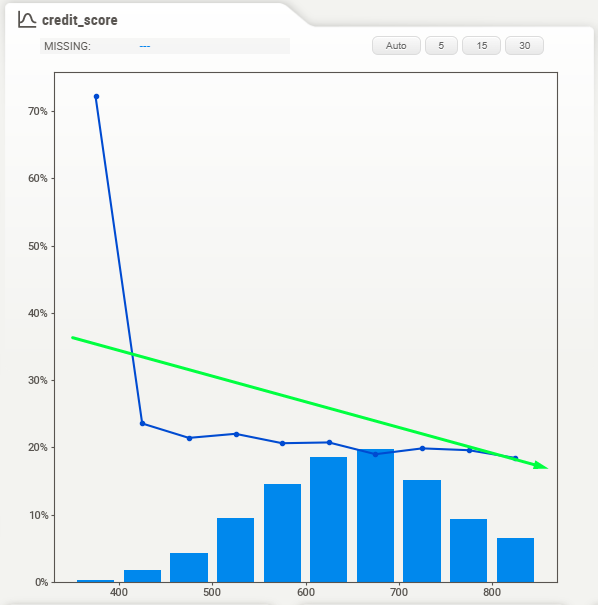

Inspect in detail below.

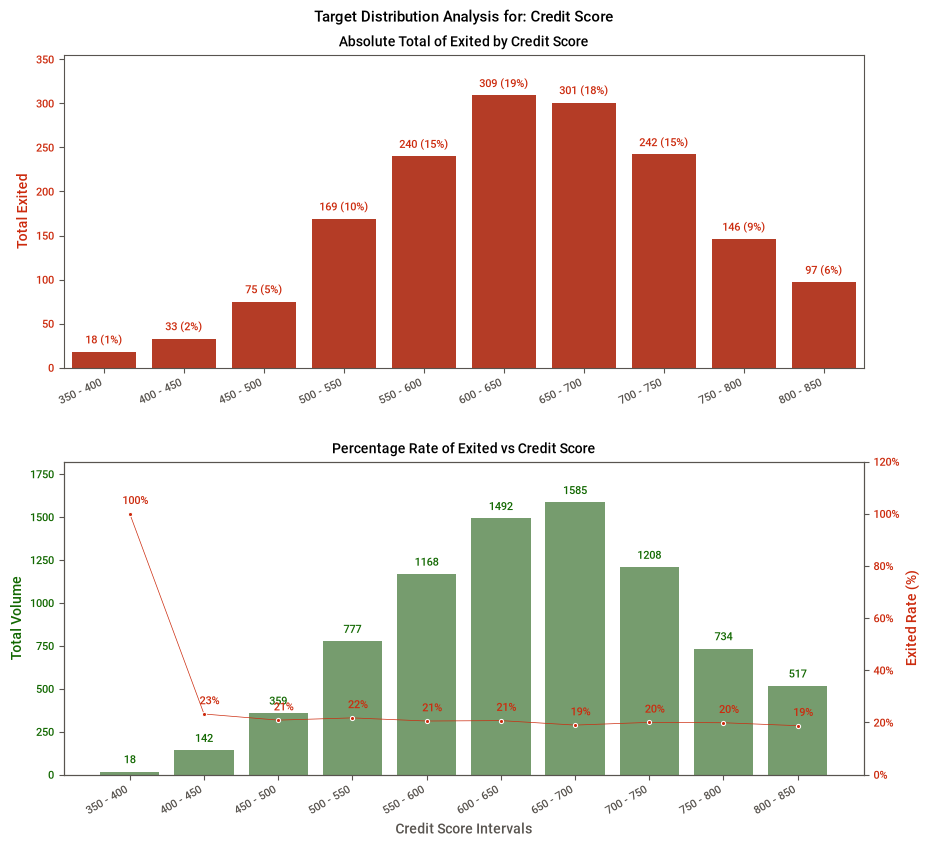

In [42]:
plot_comprehensive_target_distribution(df=train, feature='credit_score', target='exited', figsize=(10, 9), bin_size=50, abs_decimals=0, rate_decimals=0) 

The first graph shows that the absolute number of exits is higher in the intermediate credit score ranges.

However, the second graph shows porportional churn by interval. It reveals that the churn rate is around 20% for almost all of them, except for the first two, which show low volume.

H1 - The higher the credit_score, the lower the churn rate
- False: From 400-450 on, churn is almost steady.

Possible Feature Engineering:
- Create a flag has_low_score, to separate customers with credit < 450 from others, being they have a higher churn rate. 

#### H2 - Customers with a zero balance, churn at a rate at least twice as high as customers with a positive balance

Sweetviz Overview:
- There is a high percentage of customers with balance = 0, and they might have exited.

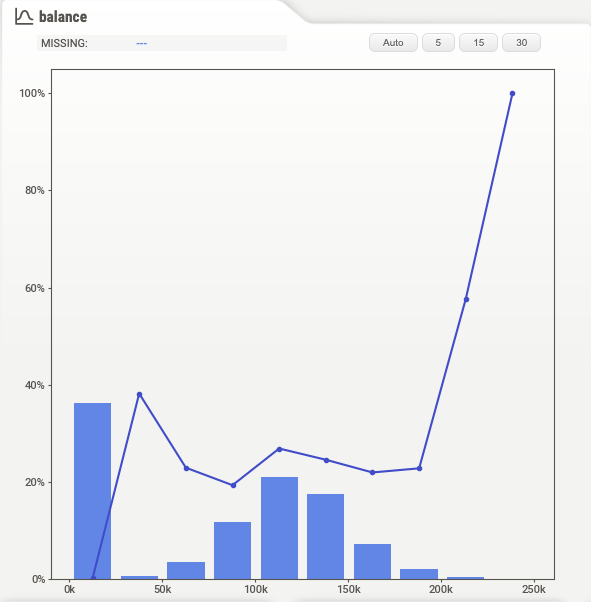



Sheetviz shows that 0-25k group has no churn at all, which is curious. 
Inspect in detail below.

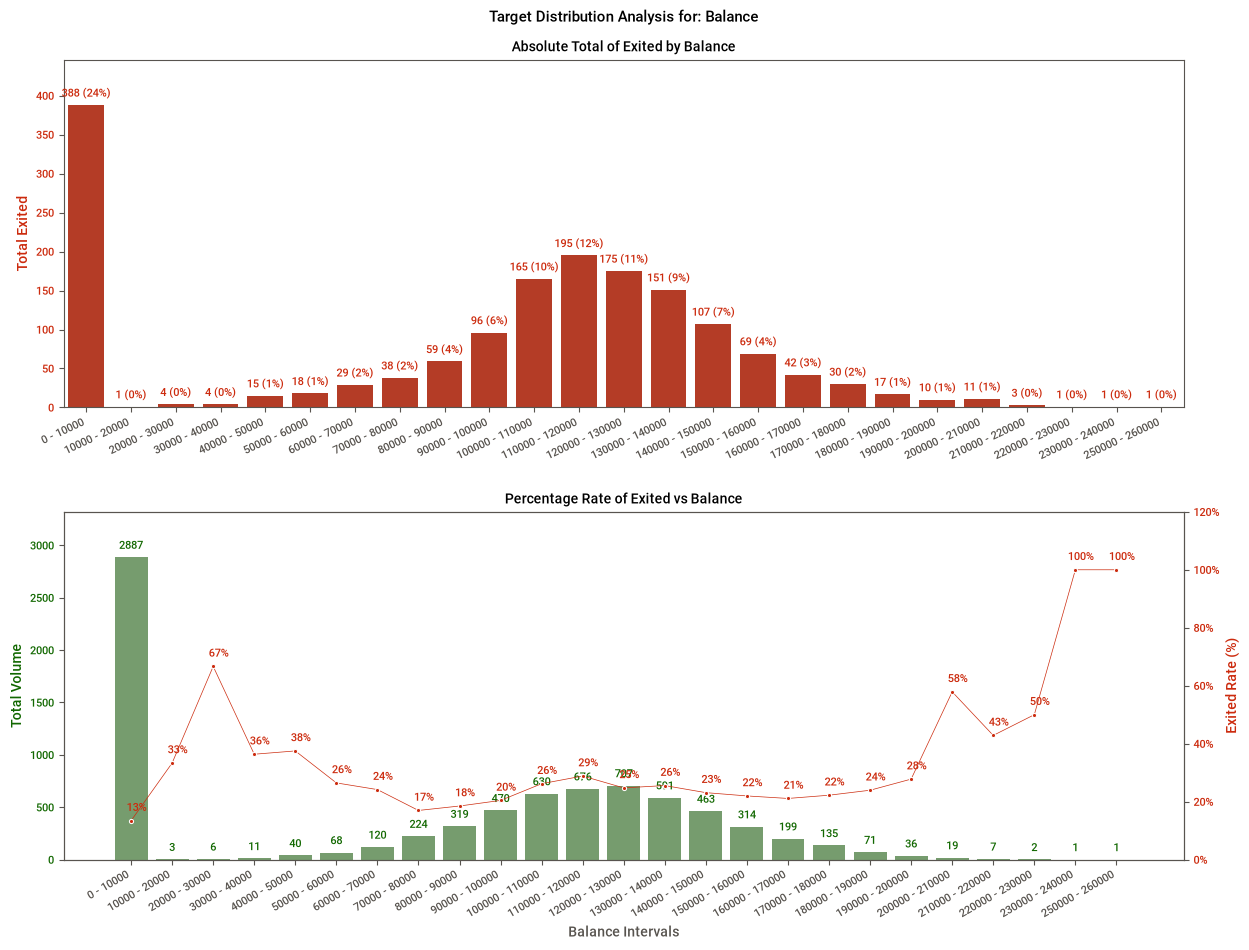

In [44]:
plot_comprehensive_target_distribution(df=train, feature='balance', target='exited', bin_size=10000, figsize=(14, 10), abs_decimals=0, rate_decimals=0)

The highest churn rates are concentrated in the intermediate balance ranges. Exceptions are tails, with low volume and reliabitily.

In [45]:
#confirm the proportion of customers with balance = 0 that have exited:
train.loc[train.balance == 0].exited.value_counts(normalize=True)*100

exited
0    86.560443
1    13.439557
Name: proportion, dtype: float64

H2 - Customers with a zero balance, churn at a rate at least twice as high as customers with a positive balance
- False: Only 13% of customers with zero balance exited, while customers with a positive balance had a higher churn rate.


Possible Feature Engineering:
- Create a new binary feature indicating whether a customer has a zero balance or not. This can help some models to diferentiate churn behavior with zero or positive balance cenarios.

#### H3 - Germany customers churn at twice the rate of other geographies

Sweetviz overview: 
- geography -> Germany customers seem to churn more: 33% of customers in Germany churned, vs 16% in France and Spain (less than half).

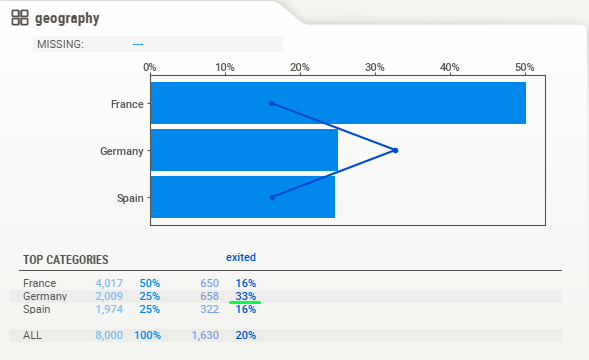


Inspect in detail below.

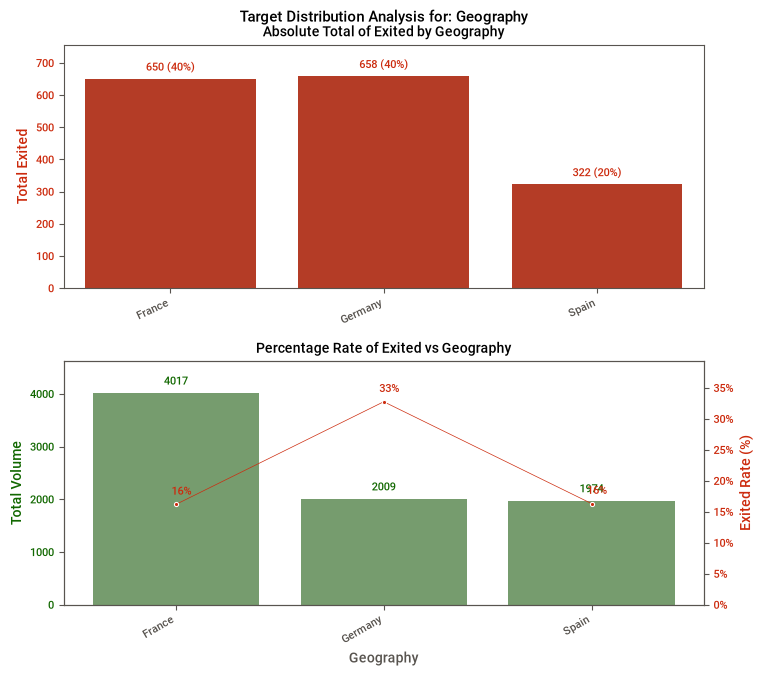

In [48]:
plot_comprehensive_target_distribution(df=train, feature='geography', target='exited', abs_decimals=0, rate_decimals=0, figsize=(8, 7)) 

H3 - Germany customers churn at twice the rate of other geographies
- True: 32% of German customers left the company, compared to 16% from other geographies.

#### H4 - Female customers churn 8% more tham male customers

Sweetviz Overview:
- gender -> female customers churn more: 25% of them churned, vs 17% of male.

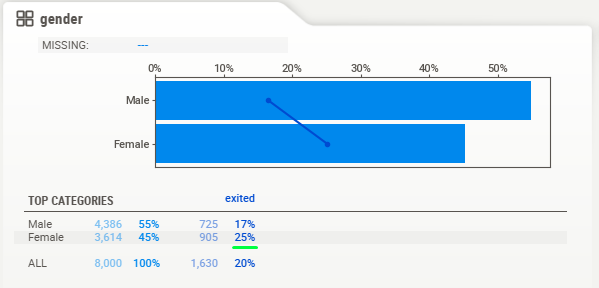


Inspect in detail below.

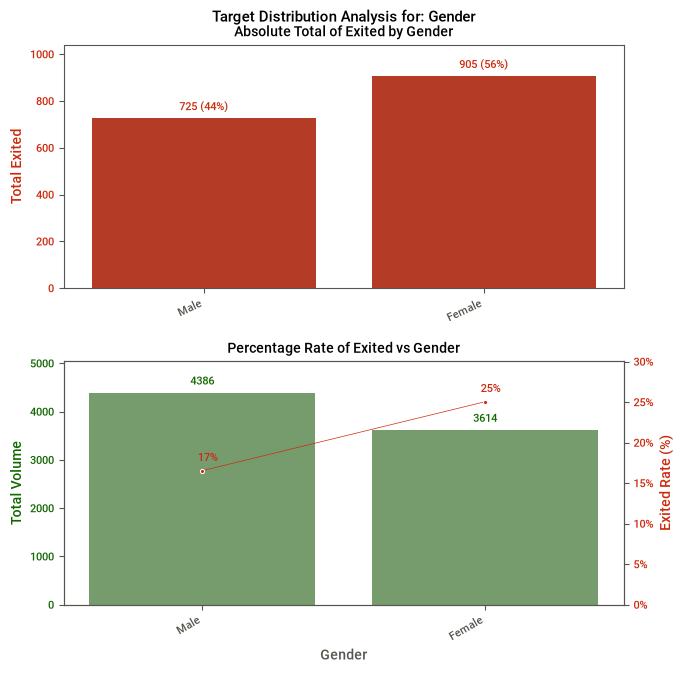

In [51]:
plot_comprehensive_target_distribution(df=train, feature='gender', target='exited', figsize=(7, 7), abs_decimals=0, rate_decimals=0)

H4 - Female customers churn 8% more tham male customers
- True: 25% of female customers churned, compared to 17% of male customers. So, the churn rate for female customers is 8% higher.

####  H5 - Customers aged 45 to 65 have a churn rate at least twice as high compared to other age groups

Sweetviz Overview:
- age -> churn seems to be more concentrated on customers with age between 45 and 65 years.

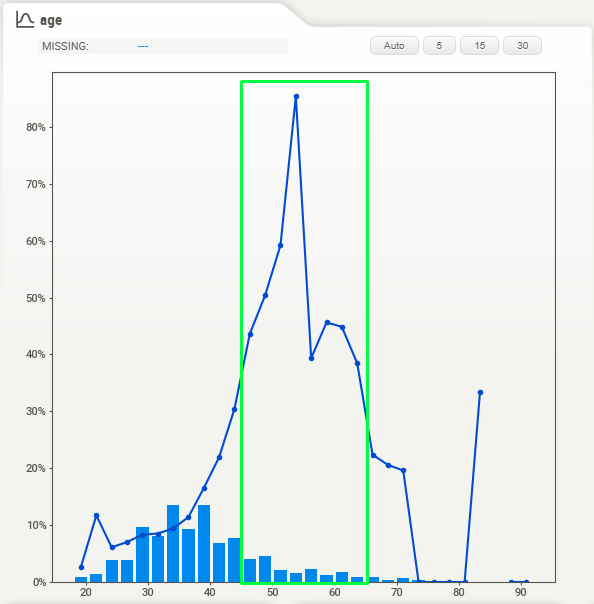


Inspect in detail below.

In [52]:
#creata a flag column to identify customers aged between 45 and 65
train_h5 = train.copy()
train_h5['age_45_65_flag'] = np.where((train_h5.age >= 45) & (train_h5.age <= 65), 'yes', 'no')
train_h5['age_45_65_flag'].value_counts(normalize=True)*100

age_45_65_flag
no     79.0875
yes    20.9125
Name: proportion, dtype: float64

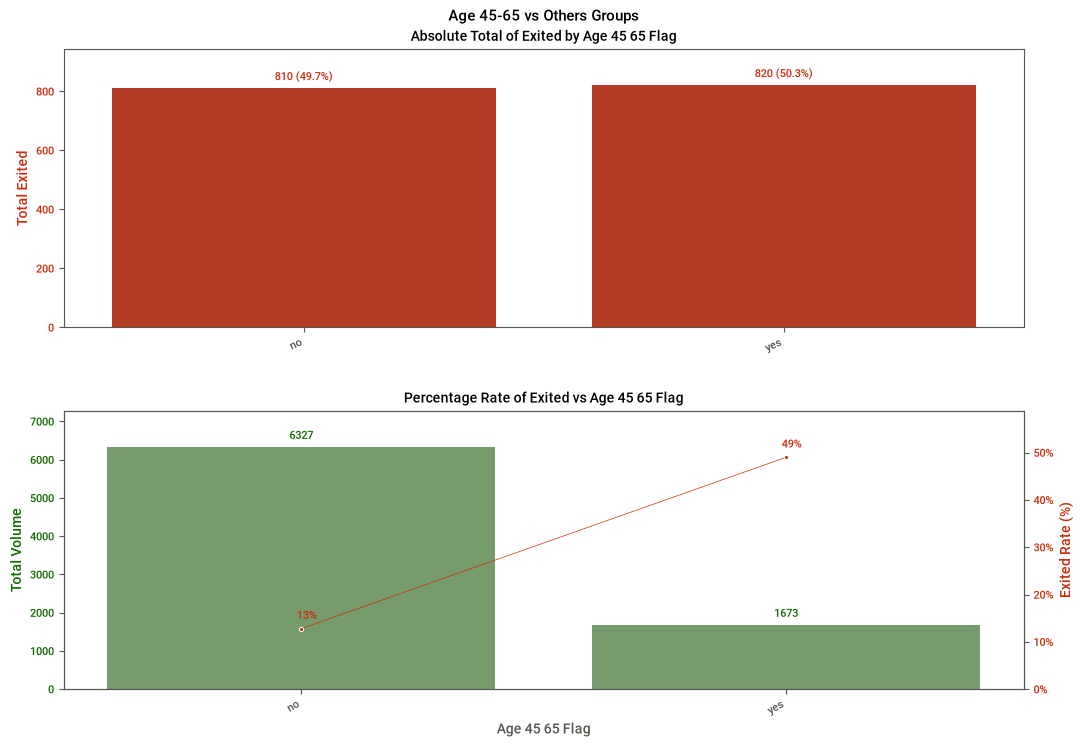

In [55]:
plot_comprehensive_target_distribution(df=train_h5, feature='age_45_65_flag', target='exited', bin_size=5, title='Age 45-65 vs Others Groups', abs_decimals=1, rate_decimals=0) 

H5 - Customers aged 45 to 65 have a churn rate at least twice as high compared to other age groups

- True: customers aged 45 to 65 churn almost 4x more than other age groups. 

Inspect ages in detail (bin = 1 year):

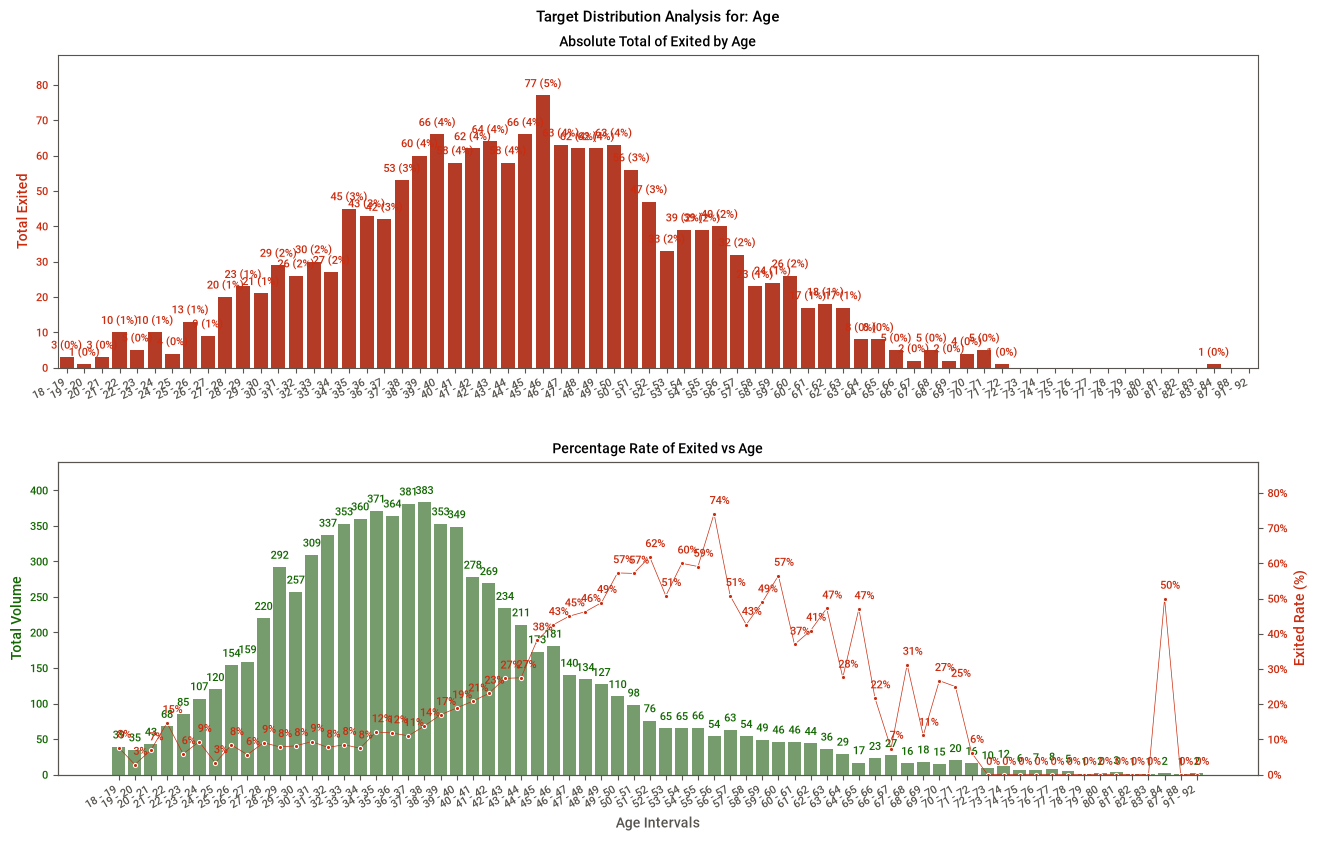

In [56]:
plot_comprehensive_target_distribution(df=train, feature='age', target='exited', bin_size=1, figsize=(15, 9), abs_decimals=0, rate_decimals=0)

Churn is stable up to 35y, then raises up to 55, then goes down.

Group customers using 5 year bins, and inspect the age groups in detail:

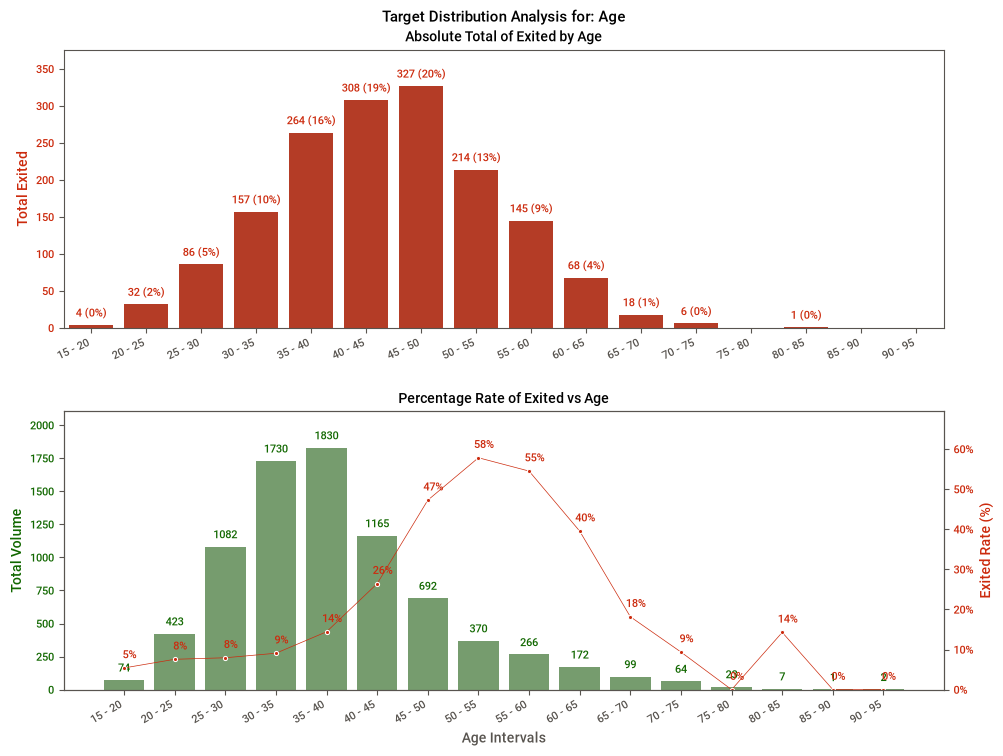

In [57]:
plot_comprehensive_target_distribution(df=train, feature='age', target='exited', bin_size=5, figsize=(11, 8), abs_decimals=0, rate_decimals=0) 

In fact, customers aged about 45-65 exhibit a considerably higher churn rate than other groups.

Possible Feature Engineering:

- Create age groups from age, with bins of 5 years, or calibrating to make groups balanced. 
    - Good for linear models, to assign a unique weight to each specific age bracket, effectively capturing that non-linear wave.
    - Bad for tree based models, because of information loss. The tree can no longer see the difference between a 21-year-old and a 24-year-old. Data was essentially hidden from the model. Also, it generates suboptimal splits, so the best cut could be at age 23, but with a bin 20-25 it can't be done. 
 
- Create age vs geography, and age vs gender, age vs balance. 
    - Thinking of business interpretability, it helps business team to act epecifically on more complex groups with most churn rates.
    - Thinking of tree based models, it would need two cuts to get to the combinations, while feeding directly the interaction would allow trees to find the signals in fewer splits. This can improve training speed and prefent overfitting, by keepint trees shallower.
        - Keep original features also, to avoid information Loss. By binning age into 5-year gaps, the granular difference between a 21-year-old and a 24-year-old is  throw away.
    - Thinking of linear models, it assumes that each variable acts independently on the target, but if young people charn fast in country A, and old people churn fast in country B, the model will miss this. Creating a country_age_bin can map this nuances directly to coefficients.

#### H6 - The higher the tenure, the lower the churn rate

Sweetviz Overview:

- Tenure -> older customers churn less: the older the customer, the lower the churn.

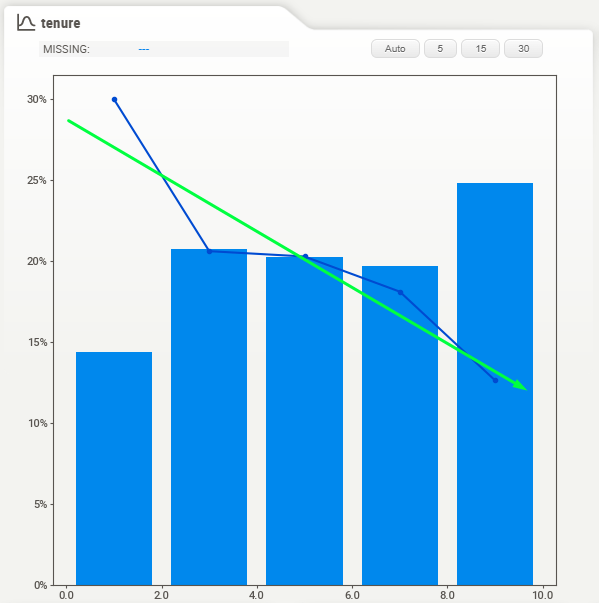


Inspect in detail below.

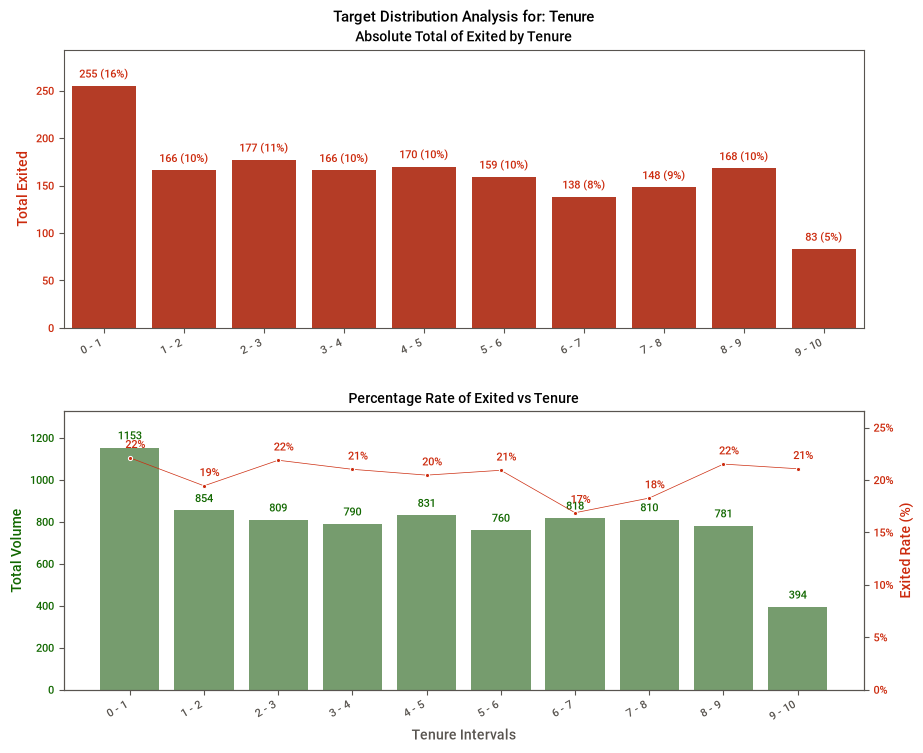

In [59]:
plot_comprehensive_target_distribution(df=train, feature='tenure', target='exited', bin_size=1, figsize=(10, 8), abs_decimals=0, rate_decimals=0)

H6 - The higher the tenure, the lower the churn rate
- False: a downward trend was not observed.

#### H7 - Customers with balance >0-50k, and with 200k +, have a churn rate at least twice as high as others

Sweetviz Overview:
- balance -> customer on the tail of the distribution seem to have churned more: except customers with a balance = 0, those with less than 50k and with more than 200k churned more.

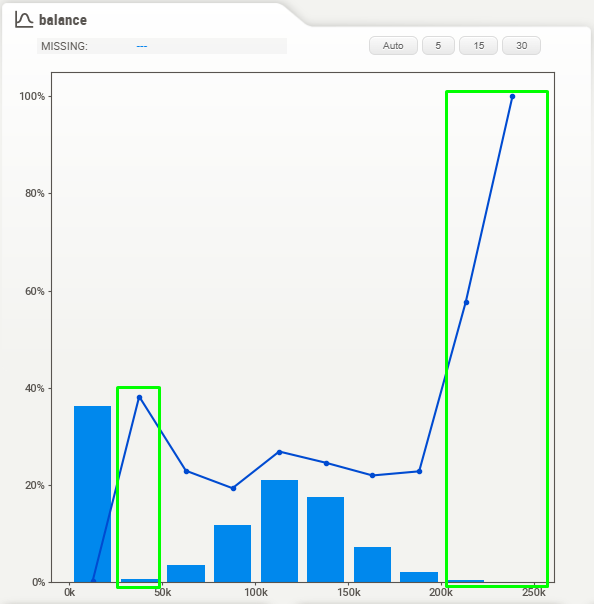

A minimum volume is required in the areas highlighted in green to consider this higher churn rate statistically significant. This will be analyzed next.

In [61]:
train_h7 = train.copy()
train_h7['balance_green_zone'] = np.where( ((train_h7.balance > 0) & (train_h7.balance < 50000)) | (train_h7.balance > 200000), 'yes', 'no')
train_h7['balance_green_zone'].value_counts(normalize=True)*100

balance_green_zone
no     98.875
yes     1.125
Name: proportion, dtype: float64

In [62]:
test_statistical_significance(train_h7, feature='balance_green_zone', value='yes', target='exited')

=== Significance Analysis for balance_green_zone == 'yes' ===
• Target Group Volume: 90 | Event Rate: 45.56%
• Others Group Volume: 7910 | Event Rate: 20.09%
• P-value: 0.000000
Statistically Significant: The difference is highly unlikely to be random chance.
Note: Although statistically significant, the absolute volume is very low (<100). Proceed with caution.


Since the volume is enough, a flag will be created to identify customers with balance >0-50k, and with 200k+

The data in green represent about 1%, but are statistically sufficient. It will be inspected next.

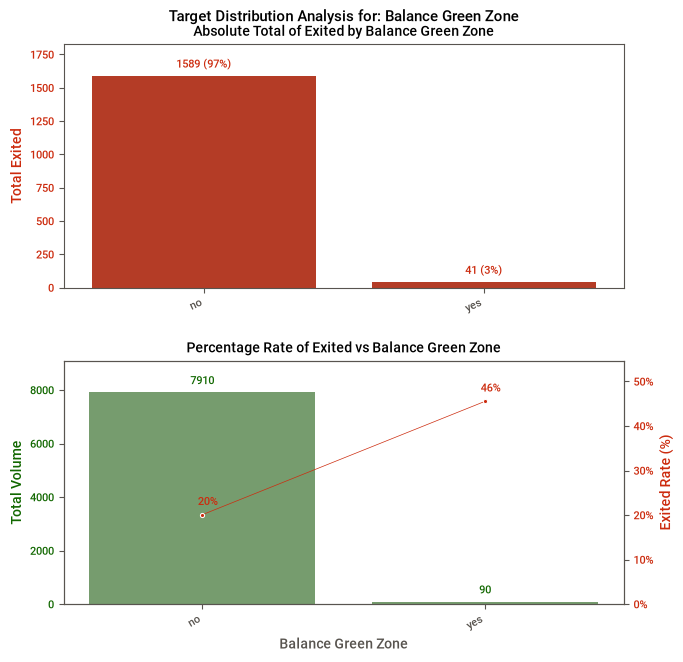

In [65]:
plot_comprehensive_target_distribution(df=train_h7, feature='balance_green_zone', target='exited', bin_size=10000, figsize=(7, 7), abs_decimals=0, rate_decimals=0)

H7 - Customers with balance >0-50k, and with 200k +, have a churn rate at least twice as high as others
- True: besides of the low volume, they have a churn rate more than twice as high as others.

Possible Feature Engineering:
- Considering tree based models, it's not a good idea to create this new flag (Balance >0-50k AND 200k+), because:
    - Profile mixed is different: they are 2 different customer prifiles. They root cause of why a $10k customer is churning is likely completely different from a $200k.
    - Sparsity issue: with only 1% of data, a tree model probably will ignore the flag, or worse, overfit if considers this split based on a tiny group.

Inspect balance with bins of 100k.

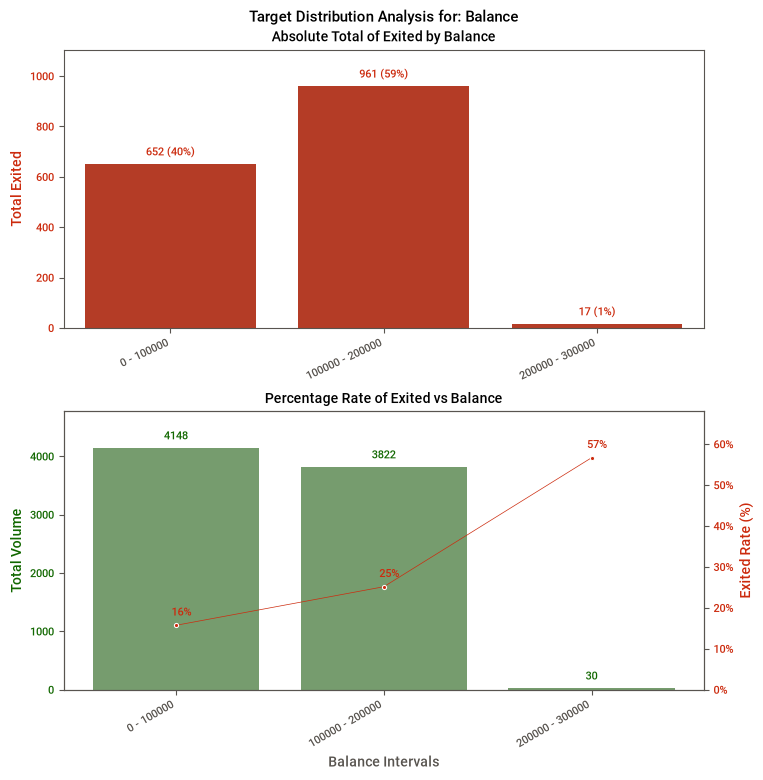

In [70]:
plot_comprehensive_target_distribution(df=train, feature='balance', target='exited', bin_size=100000, figsize=(8, 8), abs_decimals=0, rate_decimals=0)

Inspect balance with bins of 50k.

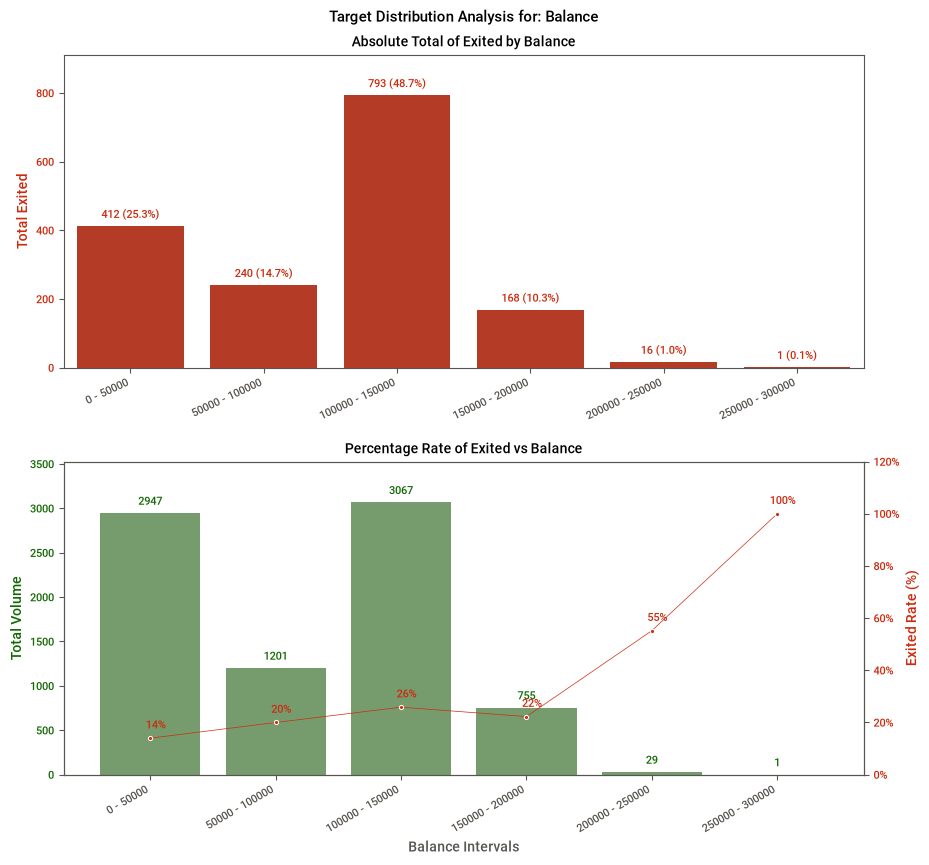

In [74]:
plot_comprehensive_target_distribution(df=train, feature='balance', target='exited', bin_size=50000, figsize=(10, 9), abs_decimals=1, rate_decimals=0)

Inspect balance with bins of 10k.

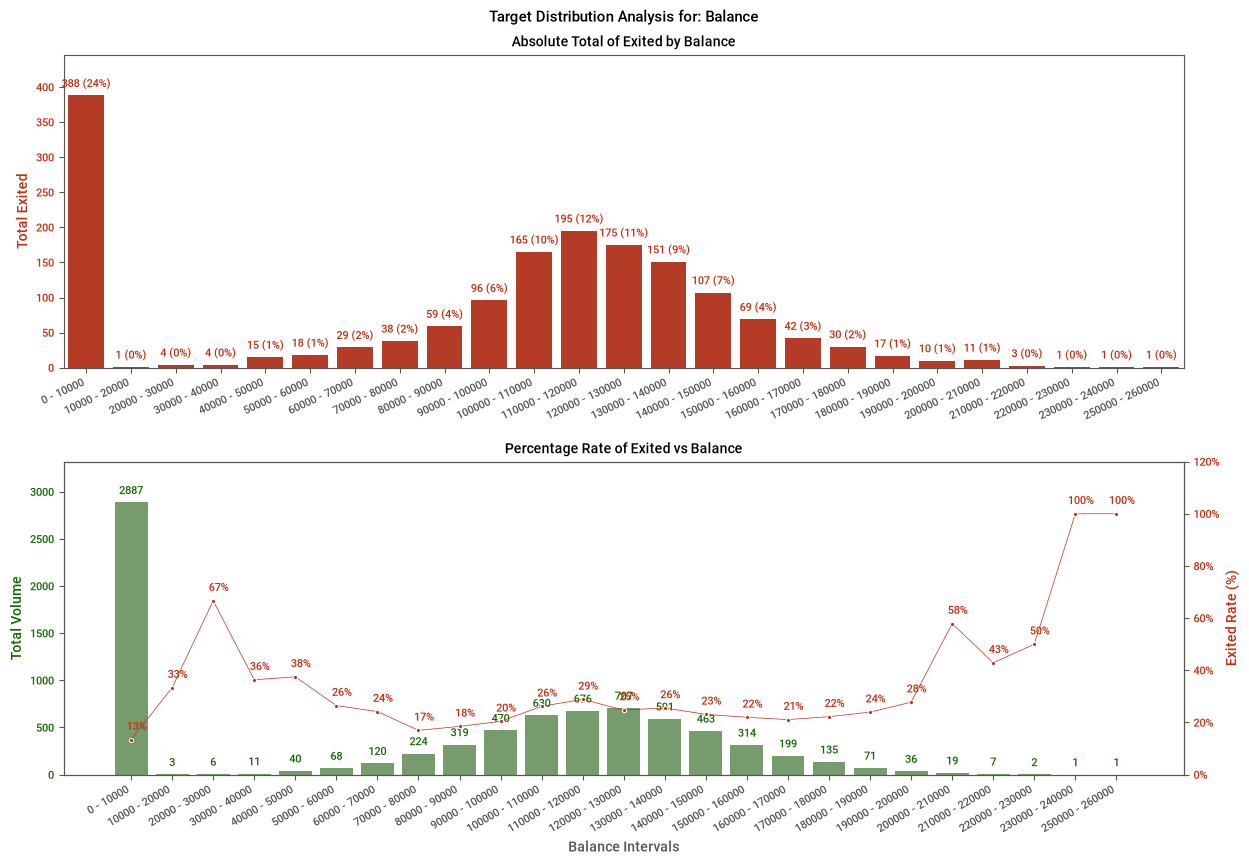

In [78]:
plot_comprehensive_target_distribution(df=train, feature='balance', target='exited', bin_size=10000, figsize=(14, 9), abs_decimals=0, rate_decimals=0)

Possible Feature Engineering:
- Creating a balance_zero flag. This was already mentioned in H2. Since there is a massife spike of exact zero balance, it helps the trees, allowing them to immediately isolate this massive cluster in a single split, preserving tree depth for more complex interactions.
- Create a clipped feature 'balance_capped', where if balance > 200k, then = 200k. This groups all extreme high-value outliers into a single stable threshold, while preserving the general continuous trend for everyone else.
- Keep raw balance as continuous. Tree algorithms will easily find the non-linear hump between $90k and $150k where volume is high and churn is stable, without bins.

#### H8 - Customers with three or more products have a churn rate at least 3 times higher than others

Sweetviz Overview:
- num_of_products:
  - customers with 2 products churned less (8%).
  - customers with 1 product churned more (28%).
  - customers with 3 products churned even more (81%).
  - 100% of customers with 4 products churned.
  
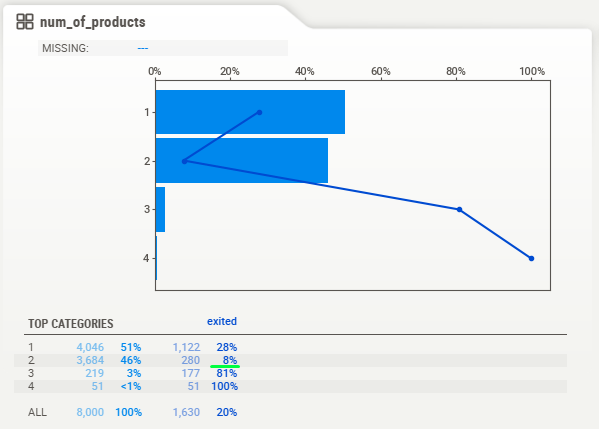


Inspect in detail below.

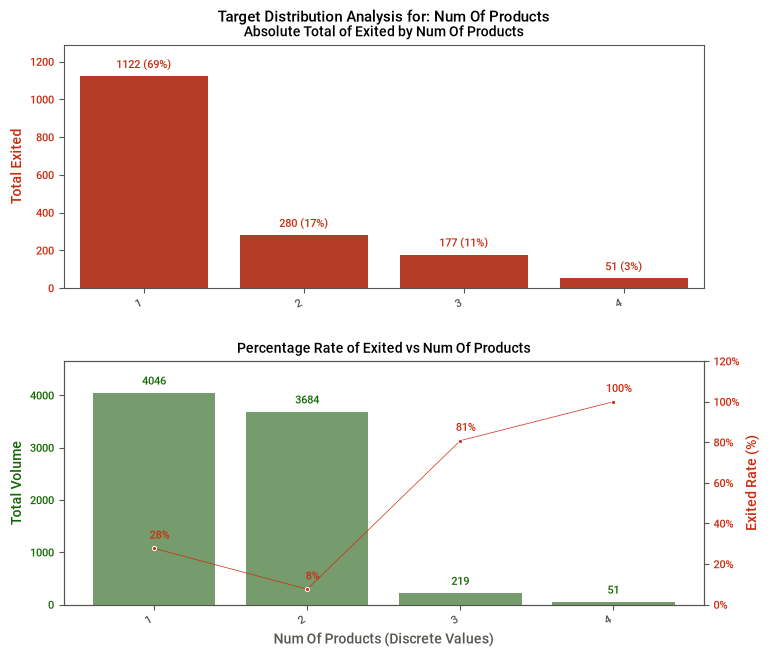

In [79]:
plot_comprehensive_target_distribution(df=train, feature='num_of_products', target='exited', bin_size=2, figsize=(8, 7), abs_decimals=0, rate_decimals=0)

Getting a customer to move from 1 product to 2 products reduces their churn risk by nearly 4x. 

H8 - Customers with three or more products have a churn rate at least 3 times higher than others
- True: They have a churn rate more than 4 times higher than others.

Possible feature engineering: 
- Creating just a single flag >2_products would throw away the insight that from 1 to 2 products, the churn drops significantly.
- Creating a scale for num_of_product: "C" for 2 products, "B" for 1 product, "A" for 3 or 4 products (3 groups): not effective, because tree models don't need help with monotonicity. As long as the values are distinct (like 1, 2, 3, 4), a tree can effortlessly isolate 2 (the lowest churn) in a single split, even if it sits right between 1 and 3. 
- Good alternatives are: 
    - One Hot Encoding, mixing 3 and 4 product. Remove then the original var.
    - Or: Target encoding, mapping its mean historical churn rate, also mixing 3 and 4 product with their combined average. Remove original var. Then, the column is purely numeric, represents actual statistical risk, and has a perfect linear relationship with the target, so any model (tree or linear) can easily read without OHE.
    - Or (best): Just mix groups 3 and 4, to create a group more representative (collapsing the tail / binning sparse categories). Grouping here makes sense, because both groups behave almost the same, having a very high churn rate. It requires zero OHE, zero string conversion, and keeps the raw, intuitive counts intact while perfectly isolating the high-risk cluster.

#### H9 - Inactive members have a churn rate 13% higher than active members

Sweetviz Overview:
- is_active_member -> inactive members churn more: 27% of churn comes from inactive members, while 14% came from active members.

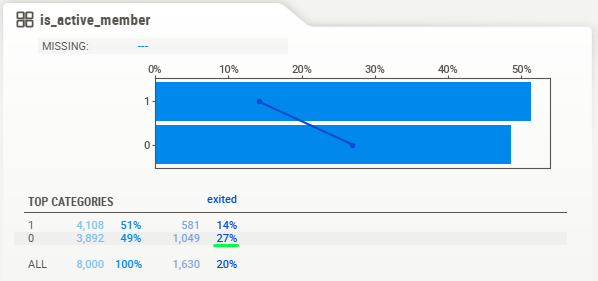


Inspect in detail below.

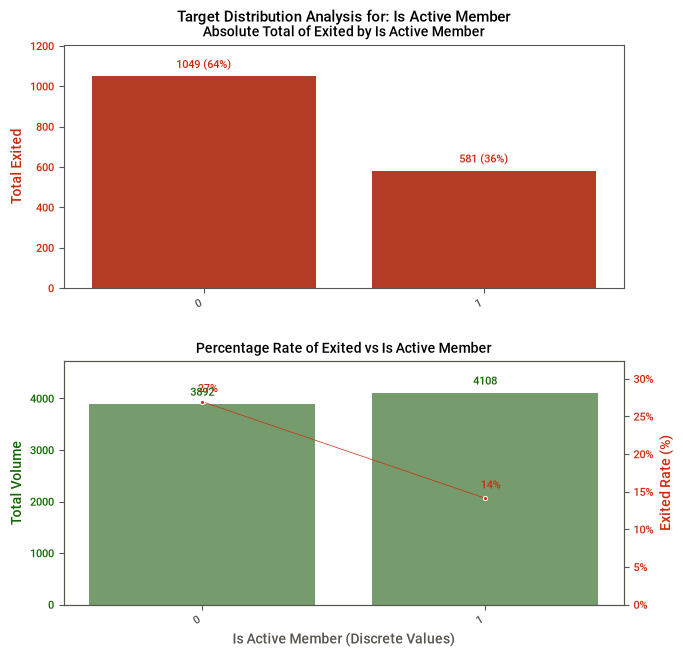

In [81]:
plot_comprehensive_target_distribution(df=train, feature='is_active_member', target='exited', figsize=(7, 7), abs_decimals=0, rate_decimals=0)

H9 - Inactive members have a churn rate 13% higher than active members
- True: 27% of inactive members churned, vs 14% of active members.

#### H10 - Customers with a credit card have the same churn rate as those without a card

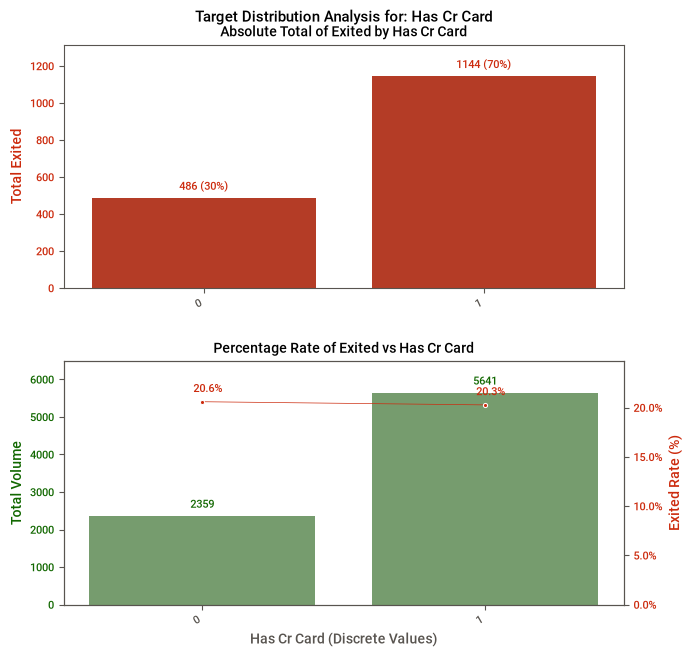

In [83]:
plot_comprehensive_target_distribution(df=train, feature='has_cr_card', target='exited', figsize=(7, 7), rate_decimals=1, abs_decimals=0)

H10 - Customers with a credit card have the same churn rate as those without a card
- True: the churn rate is arround 20% in each group.

### Hypotheses Summary

| Hypothesis | Result |
| :--- | :---: |
| **H1** - The higher the credit_score, the lower the churn rate | FALSE |
| **H2** - Customers with a zero balance, churn at a rate at least twice as high as customers with a positive balance | FALSE |
| **H3** - Germany customers churn at twice the rate of other geographies | FALSE |
| **H4** - Female customers churn 8% more than male customers | TRUE |
| **H5** - Customers aged 45 to 65 have a churn rate at least twice as high compared to other age groups | TRUE |
| **H6** - The higher the tenure, the lower the churn rate | FALSE |
| **H7** - Customers with balance >0-50k, and with 200k +, have a churn rate at least twice as high as others | TRUE |
| **H8** - Customers with three or more products have a churn rate at least three times higher than others | TRUE |
| **H9** - Inactive members have a churn rate 13% higher than active members | TRUE |
| **H10** - Customers with a credit card have the same churn rate as those without a card | TRUE |

These insights will be shared with business team, as inputs for actions aimed at reducing churn.

### Proposed Feature Engineering 

Summary of suggestions for feature engineering, extracted from the hypotheses validation. 

| Proposed Feature Engineering (Optimized for Tree-Based Models) |
| :--- |
| **`has_low_credit_score` (Flag):** Binary indicator for `CreditScore < 450` to instantly isolate the highest-risk churn segment. |
| **`is_balance_zero` (Flag):** Binary indicator for exact zero balance to allow trees to isolate this massive cluster in a single split and save tree depth. |
| **`balance_capped` (Clipped Continuous):** Cap extreme high-value outliers at `$200k` into a single stable threshold while keeping raw continuous balance intact to let the tree naturally find non-linear humps. |
| **Feature Interactions (`Age` $\times$ `Geography`, `Age` $\times$ `Gender`, `Age` $\times$ `Balance`):** Explicitly feed these cross-features so the tree can find complex customer profiles in fewer splits, keeping the model shallower and reducing overfitting (keep original features to prevent information loss). |
| **`NumOfProducts` Tail Collapse:** Group/collapse categories `3` and `4` into a single high-risk cluster (`3+`) to handle the sparse data tail without needing One-Hot Encoding, keeping the feature numeric and highly representative. |

# Model-Driven Feature Engineering

Model-Driven Feature Engineering
* Objective: Features that are discovered empirically to help the machine learning models capture complex or non-linear patterns.
* Placement: Consolidated into a structured transformation pipeline (class) immediately after Hypothesis Validation, followed by a targeted inspection of the new variables.
* Example: Discovering during bivariate analysis that risk spikes dramatically below a certain threshold on a continuous credit score variable, leading to the creation of a binary has_low_credit_score flag.

The proposed features must be created in the next cycles of the project.

# Feature Engineering

#create the new features, and then inspect them in a new EDA, to ensure: 1 no leakeage of target is happening, 2) they are clean, no nulls, etc.

# Data Prep

## Feature Filtering II

After new feature engineering, this feature selection will do the work to check and remove features that does not help the models.

# Post-Feature EDA

Do a quick bivariate/correlation check on your new features against the target variable right here to prove they actually add value.

Section 5: Export (Save the engineered dataset to a parquet/csv file).

# Next Steps

In this notebook, the raw data were processed and analyzed.

Hypotheses were validated and insights were generated. Feature engineering was also proposed. 

The next stage of the project will be developed in the modeling notebook.

In [86]:
print(train.shape)
train[:1]

(8000, 11)


,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,594,Germany,Male,28,0,142574.71,2,1,0,129084.82,0


In [87]:
# Export data to parquet format for faster loading in future steps
train.to_parquet('../data/train/v3_eda_train.parquet', index=False)